In [2]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# AWS

In [3]:
import pandas as pd
from pathlib import Path

# ── list the three manifest files ────────────────────────────────
manifest_dir = Path("aws")            # adjust if your path differs
files = [
    manifest_dir / "echo-study-directories.txt",
    manifest_dir / "echo-study-1-directories.txt",
    manifest_dir / "echo-study-2-directories.txt",
]

# ── load & reshape each, then concatenate ───────────────────────
dfs = []
for fp in files:
    raw = pd.read_csv(fp, header=None, sep="\t")     # many-cols / 1-row
    df = (
        raw.T              # cols ➜ rows
          .stack()         # drop NaNs
          .reset_index(drop=True)
          .to_frame(name="s3_key")
    )
    dfs.append(df)

all_studies = pd.concat(dfs, ignore_index=True)

# optional: drop duplicates or inspect
# all_studies = all_studies.drop_duplicates()
# print(all_studies.shape)


In [4]:
# grab the trailing numeric-dot UID (or whatever sits after the last "/")
all_studies["aws_study_id"] = (
    all_studies["s3_key"]
        .str.rstrip("/")          # drop any trailing slash
        .str.split("/")           # split on path separators
        .str[-1]                  # take the last chunk
)

# ── sanity-check ─────────────────────────────
# all_studies.head()


In [5]:
print(len(all_studies))
all_studies.head()

320854


,s3_key,aws_study_id
0,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285/,1.2.276.0.7230010.3.1.2.1714512485.1.1703111357.10353285
1,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703125808.10568238/,1.2.276.0.7230010.3.1.2.1714512485.1.1703125808.10568238
2,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703138434.10795984/,1.2.276.0.7230010.3.1.2.1714512485.1.1703138434.10795984
3,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703152147.11023754/,1.2.276.0.7230010.3.1.2.1714512485.1.1703152147.11023754
4,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703164064.11225415/,1.2.276.0.7230010.3.1.2.1714512485.1.1703164064.11225415


In [6]:
all_studies.to_csv('aws/all_studies.csv')

# Syngo Overlap
How many studies in Syngo are in the DeID key?

In [7]:
import pandas as pd
import os
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [8]:
data_dir = '/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset/Lee_Echo_Syngo'
adler = pd.read_csv(os.path.join(data_dir, 'Adler.csv'))
analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
analytics_study = pd.read_csv(os.path.join(data_dir, 'AnalyticsStudy.csv'))
department = pd.read_csv(os.path.join(data_dir, 'Department.csv'))
field_map = pd.read_csv(os.path.join(data_dir, 'FieldMap.csv'))
measurement_type = pd.read_csv(os.path.join(data_dir, 'MeasurementType.csv'))
modalities = pd.read_csv(os.path.join(data_dir, 'Modalities.csv'))
observations = pd.read_csv(os.path.join(data_dir, 'Observations.csv'))
study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))

/tmp/ipykernel_1361799/3515026001.py:3: DtypeWarning: Columns (18,19,23,24,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  analytics_report = pd.read_csv(os.path.join(data_dir, 'Analytics_Report.csv'))
/tmp/ipykernel_1361799/3515026001.py:10: DtypeWarning: Columns (6,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  study_details = pd.read_csv(os.path.join(data_dir, 'StudyDetails.csv'))


In [9]:
data_dir = '/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset/Lee_Syngo_AnalyticMeasurement'
analytics_measure = pd.read_csv(os.path.join(data_dir, 'AnalyticsMeasure_Total.csv'))

In [10]:
analytics_measure.head()

,StudyRef,MeasurementTypeRef,MeasurementName,Value,Units
0,1000710,126,Height,189.000000,cm
1,1000710,127,Weight,97.300000,kg
2,1000710,140,Regenerate Study Structured Report,1.000000,unitless
3,1000710,10650,Stress Data Persisted,1.000000,unitless
4,1000710,13019,BSA (Boyd),2.265217,m2


In [11]:
len(analytics_measure['StudyRef'].unique())

491644

In [12]:
len(study_details['STUDY_REF'].unique())

389666

# Part 1
Which studies actually on AWS are in the DeID key?

In [15]:
syngo_deid = pd.read_csv('/cluster/home/t115318uhn/echo-reports/syngo_deid.csv')

In [16]:
print(len(syngo_deid))
syngo_deid.head()

237022


,DeidentifiedStudyID,OriginalStudyID,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER
0,1.2.276.0.7230010.3.1.2.1714578744.1.1703642763.16086302,1.2.840.113680.1.103.57589.1201541989.392930,1452154,#11-02-003,20080128,93949.0,NaN
1,1.2.276.0.7230010.3.1.2.811753780.1.1703638898.16126008,1.2.840.113680.1.103.57589.1201541989.392930,1452154,#11-02-003,20080128,93949.0,NaN
2,1.2.276.0.7230010.3.1.2.845494328.1.1703200559.14758115,1.2.124.113532.36.59504.16340.20110317.142116.7522070,1157355,2393668,20110317,144215.0,25149762
3,1.2.276.0.7230010.3.1.2.811753780.1.1703538509.15238312,1.2.840.113680.1.103.51602.1120748752.341366,1546905,3233860,20050707,100552.0,NaN
4,1.2.276.0.7230010.3.1.2.845494328.1.1703543619.20977646,1.2.840.113680.1.103.51602.1137682790.772181,1501847,3278818,20060119,95950.0,NaN


# Parts 2 and 3

In [13]:
p2_p3 = pd.read_csv('/cluster/home/t115318uhn/echo-reports/data/aws/R_21_009_011_echo_study_parts2and3_results.csv')

In [14]:
print(p2_p3.shape)
p2_p3.head()

(342763, 7)


,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID
0,1563378,G0357227TSHG,20110811,70641.0,2844100.001TSHG,1.2.124.113532.25.47541.38022.20110810.133108.68626019,1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275
1,1070167,4174420,20140318,144646.0,29853237,1.2.124.113532.30763.51996.30715.20140318.141109.3525810,1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678
2,1199431,2368296,20140324,140039.0,29879866,1.2.124.113532.30763.51996.30715.20140324.134336.6750817,1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453
3,1199405,2755844,20140326,93344.0,29889926,1.2.124.113532.30763.51996.30715.20140326.95941.8525045,1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930
4,1067224,4091284,20140417,142030.0,29994381,1.2.124.113532.30763.51996.30715.20140417.121425.5552659,1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048


# Merged

In [17]:
for df in (p2_p3, syngo_deid):
    df['DeidentifiedStudyID'] = df['DeidentifiedStudyID'].astype(str)

union_deid = (
    pd.concat([p2_p3, syngo_deid], ignore_index=True)
      .drop_duplicates(subset='DeidentifiedStudyID', keep='first')  # keeps the p2_p3 version when duplicated
)

print(union_deid.shape)

(342763, 7)


In [18]:
print(union_deid.shape)
union_deid.head()

(342763, 7)


,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID
0,1563378,G0357227TSHG,20110811,70641.0,2844100.001TSHG,1.2.124.113532.25.47541.38022.20110810.133108.68626019,1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275
1,1070167,4174420,20140318,144646.0,29853237,1.2.124.113532.30763.51996.30715.20140318.141109.3525810,1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678
2,1199431,2368296,20140324,140039.0,29879866,1.2.124.113532.30763.51996.30715.20140324.134336.6750817,1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453
3,1199405,2755844,20140326,93344.0,29889926,1.2.124.113532.30763.51996.30715.20140326.95941.8525045,1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930
4,1067224,4091284,20140417,142030.0,29994381,1.2.124.113532.30763.51996.30715.20140417.121425.5552659,1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048


In [96]:
import pandas as pd

# ── 1. make sure both frames have a comparable UID column ───────────
#   • all_studies already has 'aws_study_id' (built earlier)
#   • syngo_deid has 'DeidentifiedStudyID'
#     ── strip any surrounding spaces just in case
union_deid["DeidentifiedStudyID"] = union_deid["DeidentifiedStudyID"].str.strip()

# ── 2. merge on the UID ─────────────────────────────────────────────
aws_syngo = (
    union_deid
        .merge(
            all_studies[["aws_study_id", "s3_key"]],
            left_on="DeidentifiedStudyID",
            right_on="aws_study_id",
            how="inner"          # keep only the overlap
        )
        .drop(columns=["aws_study_id"])   # helper column no longer needed
)

In [97]:
# aws_syngo now has every syngo row that exists in S3,
# plus a new 's3_key' column with the full path.
print(aws_syngo.shape)
aws_syngo.head()

(320854, 8)


,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID,s3_key
0,1563378,G0357227TSHG,20110811,70641.0,2844100.001TSHG,1.2.124.113532.25.47541.38022.20110810.133108.68626019,1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275,echo-study/1.2.276.0.7230010.3.1.2.845494328.1.1703113032.13338275/
1,1070167,4174420,20140318,144646.0,29853237,1.2.124.113532.30763.51996.30715.20140318.141109.3525810,1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703114586.7979678/
2,1199431,2368296,20140324,140039.0,29879866,1.2.124.113532.30763.51996.30715.20140324.134336.6750817,1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703115588.7992453/
3,1199405,2755844,20140326,93344.0,29889926,1.2.124.113532.30763.51996.30715.20140326.95941.8525045,1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703116173.10393930/
4,1067224,4091284,20140417,142030.0,29994381,1.2.124.113532.30763.51996.30715.20140417.121425.5552659,1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048,echo-study/1.2.276.0.7230010.3.1.2.1714578744.1.1703119511.8053048/


In [98]:
# add a column holding the top-level study directory
aws_syngo['study_dir'] = aws_syngo['s3_key'].str.partition('/')[0]   # echo-study, echo-study-1, echo-study-2

# count rows per directory
counts = aws_syngo['study_dir'].value_counts().sort_index()

print(counts)

study_dir
echo-study      215113
echo-study-1     26144
echo-study-2     79597
Name: count, dtype: int64


In [99]:
aws_syngo.to_csv('aws/aws_syngo.csv')

# Match Syngo, HeartLab

In [23]:
from matplotlib_venn import venn2

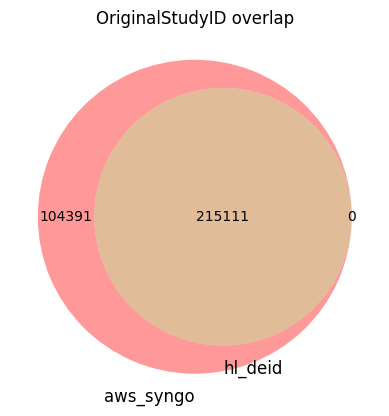

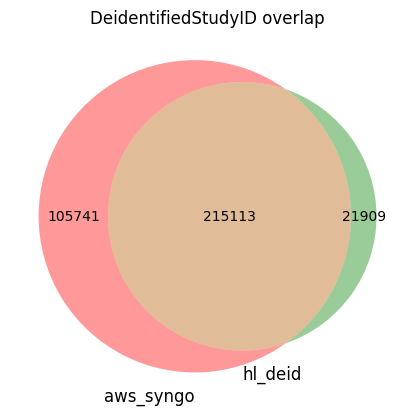

In [100]:
#––– prerequisites ––––––––––––––––––––––––––––––––––––––––––
# pip install matplotlib matplotlib-venn  (once per environment)

from matplotlib import pyplot as plt
from matplotlib_venn import venn2

# ensure IDs are strings and ignore missing values
aws_orig = set(aws_syngo["OriginalStudyID"].dropna().astype(str))
hl_orig  = set(hl_deid["OriginalStudyID"].dropna().astype(str))

plt.figure()
venn2([aws_orig, hl_orig], set_labels=("aws_syngo", "hl_deid"))
plt.title("OriginalStudyID overlap")
plt.show()

# use the correct column name that exists in *each* frame ─ adjust if needed
aws_deid = set(aws_syngo["DeidentifiedStudyID"].dropna().astype(str))
hl_deid_ids = set(hl_deid["DeidentifiedStudyID"].dropna().astype(str))

plt.figure()
venn2([aws_deid, hl_deid_ids], set_labels=("aws_syngo", "hl_deid"))
plt.title("DeidentifiedStudyID overlap")
plt.show()

In [32]:
hl_deid = pd.read_csv('/cluster/projects/bwanggroup/echo_reports/echo-reports/data/dataset/echo-study-deid.csv')

In [73]:
aws_syngo_hl = aws_uhn.merge(
    hl_deid,
    on="OriginalStudyID",
    how="left",
    suffixes=("_syngo", "_hl")
)

In [77]:
aws_syngo_exclusive = aws_syngo_hl[aws_syngo_hl["DeidentifiedStudyID_hl"].isna()].reset_index(drop=True)
len(aws_syngo_exclusive)

105741

### **View OID Duplicates (Syngo)**

In [95]:
aws_syngo_exclusive['OriginalStudyID'].value_counts().head()

OriginalStudyID
1.3.12.2.1107.5.8.9.10001229899769.20180718141326004    7
1.3.12.2.1107.5.8.9.10001229899769.20190111091033558    4
1.3.12.2.1107.5.8.9.10001229899769.20180904140120367    4
1.3.12.2.1107.5.8.9.10001229899769.20190111100213768    4
1.3.12.2.1107.5.8.9.10001229899769.20180718135154009    4
Name: count, dtype: int64

In [89]:
# Group the same OriginalStudyIDs together
aws_syngo_exclusive = aws_syngo_exclusive.sort_values(
    by=["OriginalStudyID", "OriginalStudyID"], 
    key=lambda col: col.map(aws_syngo_hl["OriginalStudyID"].value_counts()), 
    ascending=False
).reset_index(drop=True)
aws_syngo_exclusive.head()

,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID_syngo,s3_key,study_dir,OriginalPatientID,DeidentifiedStudyID_hl,DeidentifiedPatientID
0,1626751,4499434,20180718,145612.0,37302354,1.3.12.2.1107.5.8.9.10001229899769.20180718141326004,1.2.276.0.7230010.3.1.2.895627313.1.1724496589.1079780,echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724496589.1079780/,echo-study-2,NaN,NaN,NaN
1,1626751,4499434,20180718,145612.0,37302354,1.3.12.2.1107.5.8.9.10001229899769.20180718141326004,1.2.276.0.7230010.3.1.2.895627313.1.1724503633.1103648,echo-study-2/1.2.276.0.7230010.3.1.2.895627313.1.1724503633.1103648/,echo-study-2,NaN,NaN,NaN
2,1626751,4499434,20180718,145612.0,37302354,1.3.12.2.1107.5.8.9.10001229899769.20180718141326004,1.2.276.0.7230010.3.1.2.842097970.1.1724500145.596127,echo-study-2/1.2.276.0.7230010.3.1.2.842097970.1.1724500145.596127/,echo-study-2,NaN,NaN,NaN
3,1626751,4499434,20180718,145612.0,37302354,1.3.12.2.1107.5.8.9.10001229899769.20180718141326004,1.2.276.0.7230010.3.1.2.895693665.1.1724492987.2126173,echo-study-2/1.2.276.0.7230010.3.1.2.895693665.1.1724492987.2126173/,echo-study-2,NaN,NaN,NaN
4,1626751,4499434,20180718,145612.0,37302354,1.3.12.2.1107.5.8.9.10001229899769.20180718141326004,1.2.276.0.7230010.3.1.2.842097970.1.1724503745.608884,echo-study-2/1.2.276.0.7230010.3.1.2.842097970.1.1724503745.608884/,echo-study-2,NaN,NaN,NaN


In [86]:
aws_syngo_exclusive.to_csv('aws/aws_syngo_exclusive_0806.csv')

### **Filter HeartLab IDs on AWS**

In [79]:
# Filter for the rows where DeidentifiedStudyID_hl actually corresponds to a study folder on AWS
aws_syngo_hl_matched = aws_syngo_hl[
    aws_syngo_hl["DeidentifiedStudyID_hl"].isin(all_studies["aws_study_id"])
].reset_index(drop=True)

In [80]:
aws_syngo_hl_matched.head()

,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID_syngo,s3_key,study_dir,OriginalPatientID,DeidentifiedStudyID_hl,DeidentifiedPatientID
0,1499564,2438474,20060223,171111.0,NaN,1.2.840.113680.1.103.51602.1140732671.865987,1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955/,echo-study,2438474,1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955,255004be-fa98-4f46-97f7-97b1ffaa5f04
1,1499304,2488405,20060302,172955.0,NaN,1.2.840.113680.1.103.51602.1141338595.945586,1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329/,echo-study,2488405,1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329,9640588b-93cf-4196-9cdf-902ad89313b2
2,1536460,2490775,20060508,164230.0,NaN,1.2.840.113680.1.103.51602.1147124550.314295,1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984/,echo-study,2490775,1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984,f0c813aa-8b12-466b-8619-dd880042071a
3,1499594,2731101,20060223,95746.0,NaN,1.2.840.113680.1.103.65868.1140706666.984437,1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208/,echo-study,2731101,1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208,1e820a6d-c6b3-4bcc-bb33-b75038e4bf54
4,1500478,2211462,20060209,181245.0,NaN,1.2.840.113680.1.103.51602.1139526765.115643,1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145/,echo-study,2211462,1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145,d08b76ad-0f7e-446c-b597-02841aa77153


In [81]:
total_rows = len(aws_syngo_hl_matched)

same_mask = aws_syngo_hl_matched["DeidentifiedStudyID_syngo"] == aws_syngo_hl_matched["DeidentifiedStudyID_hl"]

same_count = same_mask.sum()
diff_count = total_rows - same_count

same_pct = same_count / total_rows * 100
diff_pct = diff_count / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Same ID: {same_count} ({same_pct:.2f}%)")
print(f"Different ID: {diff_count} ({diff_pct:.2f}%)")


Total rows: 215117
Same ID: 215113 (100.00%)
Different ID: 4 (0.00%)


In [83]:
aws_syngo_hl_matched = aws_syngo_hl_matched[
    aws_syngo_hl_matched["DeidentifiedStudyID_syngo"] == aws_syngo_hl_matched["DeidentifiedStudyID_hl"]
].reset_index(drop=True)

In [85]:
aws_syngo_hl_matched.to_csv('aws/aws_heartlab_0806.csv')

### **View OID Duplicates (HeartLab)**

In [87]:
aws_syngo_hl_matched['OriginalStudyID'].value_counts().head()

OriginalStudyID
1.2.840.113680.1.103.68153.1199721521.722252    2
1.2.840.113680.1.103.65868.1217273905.442102    2
1.2.840.113680.1.103.57589.1291986380.314698    1
1.2.840.113680.1.103.57589.1320239240.620733    1
1.2.840.113680.1.103.57589.1395144326.681784    1
Name: count, dtype: int64

In [93]:
# Group the same OriginalStudyIDs together
aws_syngo_hl_matched = aws_syngo_hl_matched.sort_values(
    by=["OriginalStudyID", "OriginalStudyID"], 
    key=lambda col: col.map(aws_syngo_hl["OriginalStudyID"].value_counts()), 
    ascending=False
).reset_index(drop=True)
aws_syngo_hl_matched.head()

,STUDY_REF,PATIENT_ID,STUDY_DATE,STUDY_TIME,ACCESSION_NUMBER,OriginalStudyID,DeidentifiedStudyID_syngo,s3_key,study_dir,OriginalPatientID,DeidentifiedStudyID_hl,DeidentifiedPatientID
0,1499564,2438474,20060223,171111.0,NaN,1.2.840.113680.1.103.51602.1140732671.865987,1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955/,echo-study,2438474,1.2.276.0.7230010.3.1.2.1714512485.1.1703544715.18483955,255004be-fa98-4f46-97f7-97b1ffaa5f04
1,1499304,2488405,20060302,172955.0,NaN,1.2.840.113680.1.103.51602.1141338595.945586,1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329/,echo-study,2488405,1.2.276.0.7230010.3.1.2.1714512485.1.1703553495.18555329,9640588b-93cf-4196-9cdf-902ad89313b2
2,1536460,2490775,20060508,164230.0,NaN,1.2.840.113680.1.103.51602.1147124550.314295,1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984/,echo-study,2490775,1.2.276.0.7230010.3.1.2.1714512485.1.1703547243.18502984,f0c813aa-8b12-466b-8619-dd880042071a
3,1499594,2731101,20060223,95746.0,NaN,1.2.840.113680.1.103.65868.1140706666.984437,1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208/,echo-study,2731101,1.2.276.0.7230010.3.1.2.1714512485.1.1703683762.19962208,1e820a6d-c6b3-4bcc-bb33-b75038e4bf54
4,1500478,2211462,20060209,181245.0,NaN,1.2.840.113680.1.103.51602.1139526765.115643,1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145,echo-study/1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145/,echo-study,2211462,1.2.276.0.7230010.3.1.2.1714512485.1.1703544369.18481145,d08b76ad-0f7e-446c-b597-02841aa77153
